# Exploratory Data Analysis (EDA) on Used Car Dataset

## Internship
Thiranex Data Science Internship

## Objective

Perform Exploratory Data Analysis on the Cardekho used car dataset to discover patterns, relationships, and insights using statistics and visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme()

%matplotlib inline

In [4]:
df = pd.read_csv("../Data/cardekho_cleaned.csv")

In [5]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0


In [6]:
df.shape

(6926, 12)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6926 entries, 0 to 6925
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                6926 non-null   str    
 1   year                6926 non-null   int64  
 2   selling_price       6926 non-null   int64  
 3   km_driven           6926 non-null   int64  
 4   fuel                6926 non-null   str    
 5   seller_type         6926 non-null   str    
 6   transmission        6926 non-null   str    
 7   owner               6926 non-null   str    
 8   mileage(km/ltr/kg)  6926 non-null   float64
 9   engine              6926 non-null   float64
 10  max_power           6926 non-null   float64
 11  seats               6926 non-null   float64
dtypes: float64(4), int64(3), str(5)
memory usage: 649.4 KB


In [8]:
df.describe()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,max_power,seats
count,6926.000000,6.926000e+03,6.926000e+03,6926.000000,6926.000000,6926.000000,6926.000000
mean,2013.420300,5.172707e+05,7.399568e+04,19.464550,1425.398787,87.551527,5.421600
std,4.078286,5.197670e+05,5.835810e+04,3.987878,487.026967,31.311523,0.972171
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,0.000000,2.000000
25%,2011.000000,2.500000e+05,4.000000e+04,16.950000,1197.000000,68.000000,5.000000
50%,2014.000000,4.000000e+05,7.000000e+04,19.440000,1248.000000,81.830000,5.000000
75%,2017.000000,6.335000e+05,1.000000e+05,22.320000,1498.000000,99.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,400.000000,14.000000


In [9]:
df.isnull().sum()

name                  0
year                  0
selling_price         0
km_driven             0
fuel                  0
seller_type           0
transmission          0
owner                 0
mileage(km/ltr/kg)    0
engine                0
max_power             0
seats                 0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

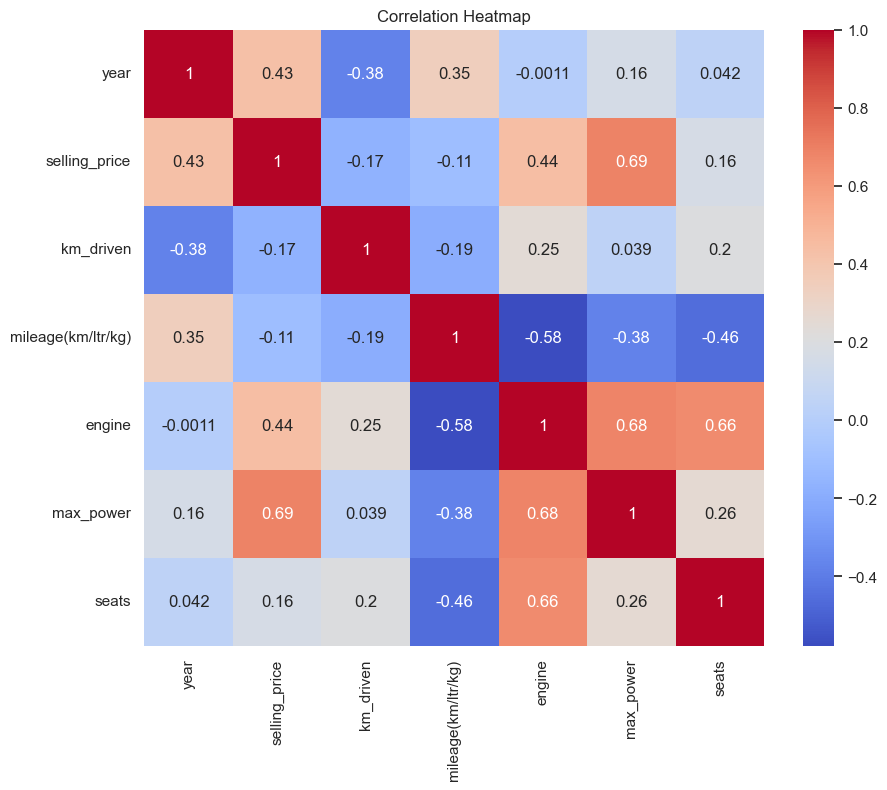

In [11]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig("../Images/correlation_heatmap.png")

plt.show()

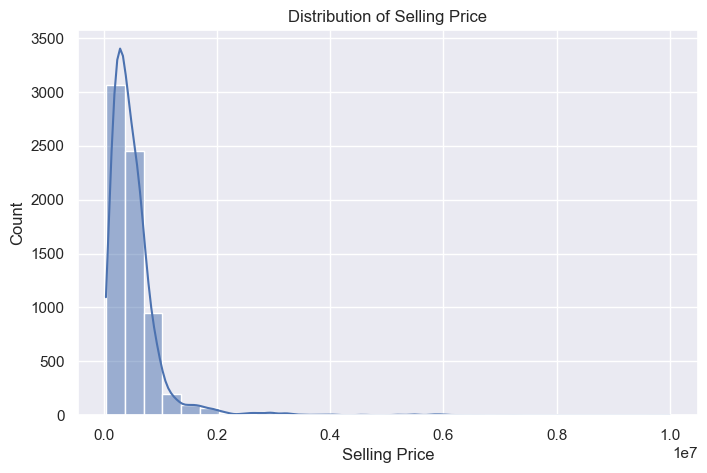

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["selling_price"], bins=30, kde=True)

plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Count")

plt.savefig("../Images/selling_price_distribution.png")

plt.show()

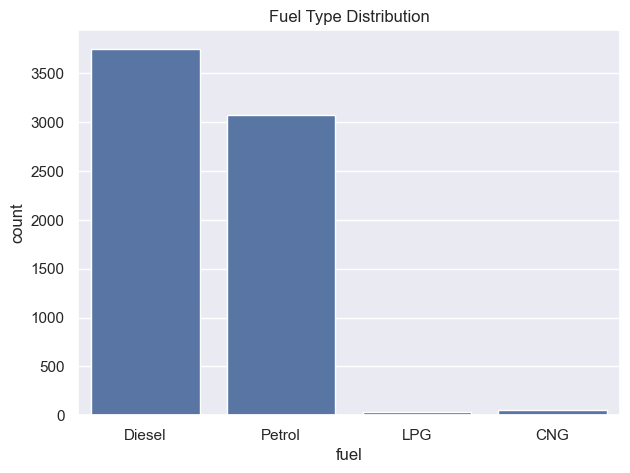

In [13]:
plt.figure(figsize=(7,5))

sns.countplot(x="fuel", data=df)

plt.title("Fuel Type Distribution")

plt.savefig("../Images/fuel_distribution.png")

plt.show()

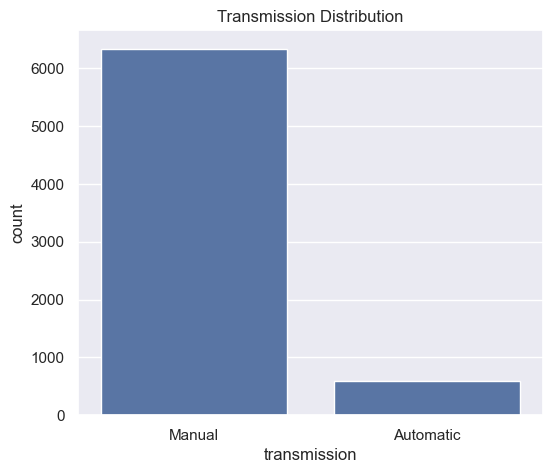

In [14]:
plt.figure(figsize=(6,5))

sns.countplot(x="transmission", data=df)

plt.title("Transmission Distribution")

plt.savefig("../Images/transmission_distribution.png")

plt.show()

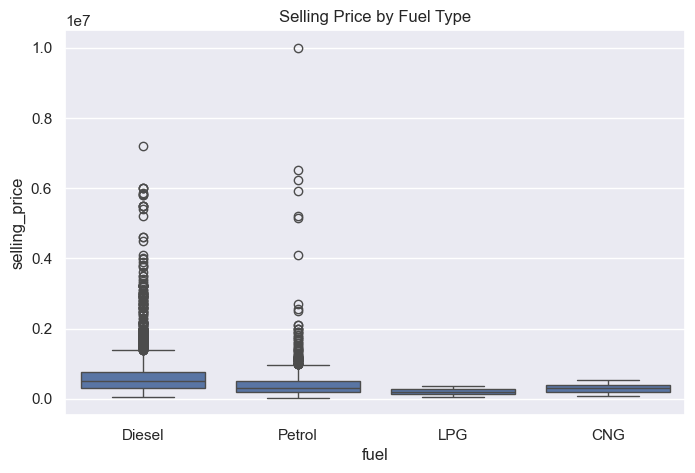

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="fuel",
    y="selling_price",
    data=df
)

plt.title("Selling Price by Fuel Type")

plt.savefig("../Images/price_by_fuel.png")

plt.show()

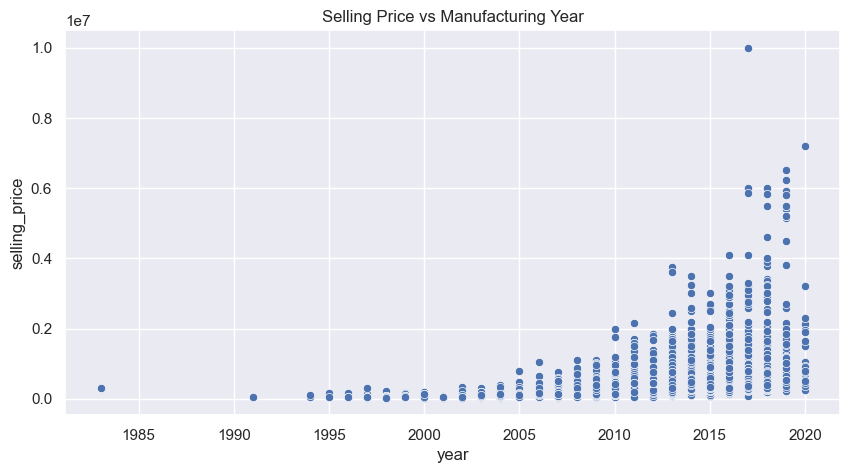

In [16]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    x="year",
    y="selling_price",
    data=df
)

plt.title("Selling Price vs Manufacturing Year")

plt.savefig("../Images/price_vs_year.png")

plt.show()

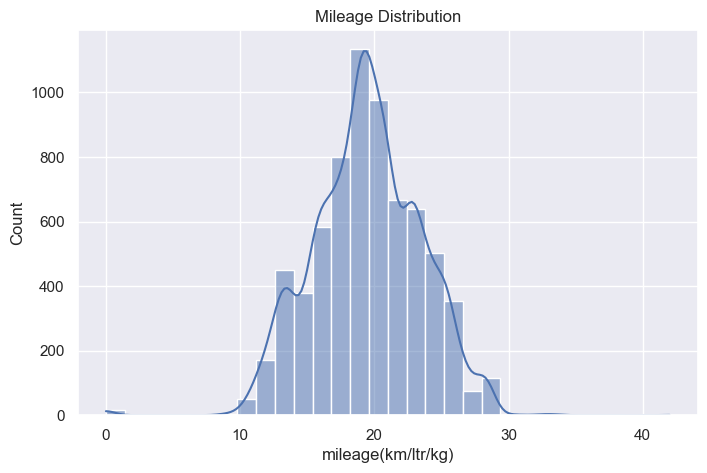

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["mileage(km/ltr/kg)"],
    bins=30,
    kde=True
)

plt.title("Mileage Distribution")

plt.savefig("../Images/mileage_distribution.png")

plt.show()

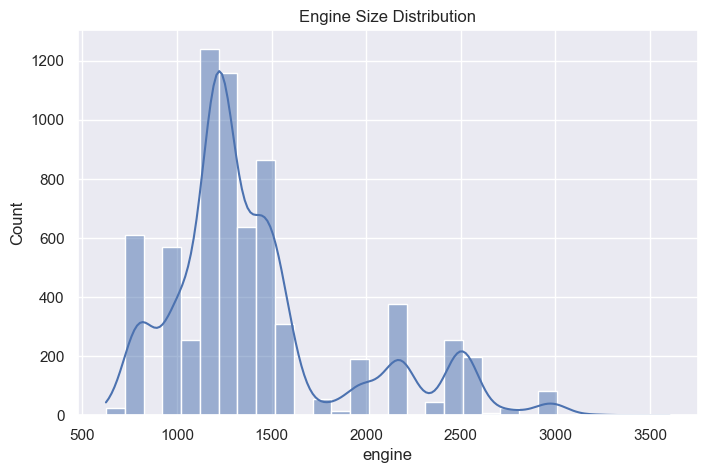

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["engine"],
    bins=30,
    kde=True
)

plt.title("Engine Size Distribution")

plt.savefig("../Images/engine_distribution.png")

plt.show()

In [19]:
df["brand"] = df["name"].str.split().str[0]

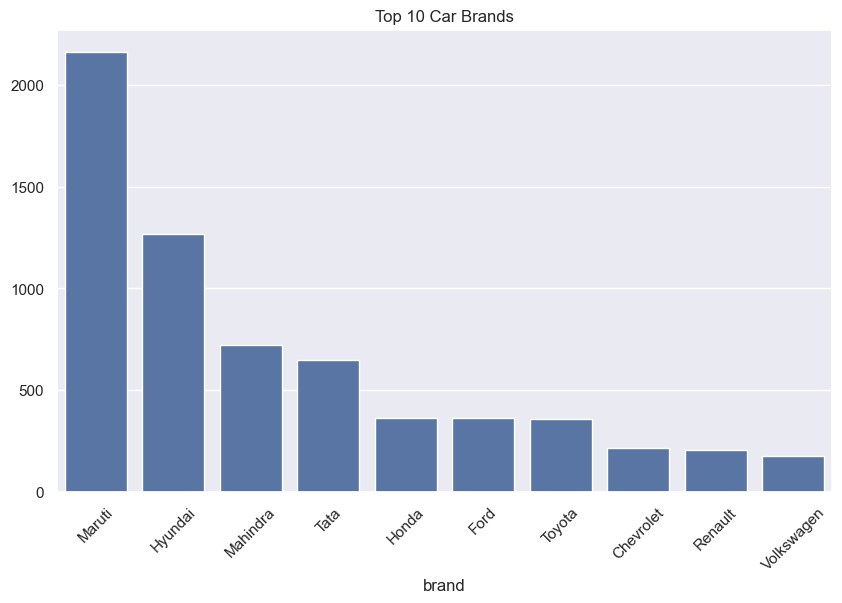

In [20]:
plt.figure(figsize=(10,6))

top_brands = df["brand"].value_counts().head(10)

sns.barplot(
    x=top_brands.index,
    y=top_brands.values
)

plt.xticks(rotation=45)

plt.title("Top 10 Car Brands")

plt.savefig("../Images/top_brands.png")

plt.show()

In [21]:
df.groupby("fuel")["selling_price"].mean().sort_values(ascending=False)

fuel
Diesel    639727.768842
Petrol    375688.966526
CNG       300499.946429
LPG       200421.052632
Name: selling_price, dtype: float64

In [22]:
df.groupby("transmission")["selling_price"].mean()

transmission
Automatic    1.309712e+06
Manual       4.442991e+05
Name: selling_price, dtype: float64

In [23]:
df.groupby("owner")["selling_price"].mean()

owner
First Owner             6.154044e+05
Fourth & Above Owner    2.244704e+05
Second Owner            3.856972e+05
Test Drive Car          4.403800e+06
Third Owner             2.812509e+05
Name: selling_price, dtype: float64

# Insights

- The dataset contains clean records with no missing values.
- Selling prices are positively skewed, indicating a few high-value cars.
- Manual transmission vehicles are more common than automatic ones.
- Petrol and Diesel cars dominate the dataset.
- Newer vehicles generally have higher selling prices.
- Engine size shows a positive relationship with selling price.
- Most cars have mileage between 15 and 25 km/ltr.
- Maruti is among the most represented brands in the dataset.

In [24]:
df.to_csv("../Data/eda_processed.csv", index=False)

print("EDA dataset saved successfully!")

EDA dataset saved successfully!
